# Sales Meeting Charts
Plan to present in monthly sales meetings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from openpyxl import load_workbook
from pathlib import Path
data_file = Path('sales_analysis_data.xlsx')
assert data_file.exists(), f'{data_file} not found'
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
wb = load_workbook(data_file, data_only=True)
def read_year(sheet_name):
    ws = wb[sheet_name]
    written  = [ws.cell(row=2, column=2 + i).value for i in range(12)]
    invoiced = [ws.cell(row=3, column=2 + i).value for i in range(12)]
    goal     = [ws.cell(row=4, column=2 + i).value for i in range(12)]
    return written, invoiced, goal
data = {}
for yr in [2023, 2024, 2025, 2026]:
    w, inv, g = read_year(str(yr))
    data[yr] = {'written': w, 'invoiced': inv, 'goal': g}
months_closed_2026 = sum(1 for v in data[2026]['written'] if v is not None)
print(f'Completed Months in 2026 = {months_closed_2026}')

df = pd.DataFrame({yr: data[yr]['written'] for yr in data}, index=months)
df.index.name = 'Month'
df

Completed Months in 2026 = 4


,2023,2024,2025,2026
Month,,,,
Jan,852827.79,844942.96,1445682.85,955153.67
Feb,1941736.86,1837520.97,2637558.88,1915665.26
Mar,2877487.69,2592888.01,3812147.03,3150003.07
Apr,3609987.30,3662612.72,5027855.31,4513201.07
May,4825078.24,4554326.79,6264607.59,NaN
Jun,5866636.13,5701911.73,7193093.03,NaN
Jul,6423941.43,6717868.44,8392742.67,NaN
Aug,7540840.14,7751572.35,9415927.40,NaN
Sep,8338579.68,8712512.12,10465391.08,NaN


## YoY Growth

In [2]:
complete_years = [yr for yr in data if data[yr]['written'][-1] is not None]
year_end = {yr: data[yr]['written'][-1] for yr in complete_years}
year_goal = {yr: data[yr]['goal'][-1] for yr in data} 
growth = pd.DataFrame({'Year End Written $': [year_end[y] for y in complete_years],'Goal $': [year_goal[y] for y in complete_years],}, index=complete_years)
growth['Goal Reached'] = growth['Year End Written $'] >= growth['Goal $']
growth['Over or Under $'] = growth['Year End Written $'] - growth['Goal $']
growth['YoY Growth %'] = growth['Year End Written $'].pct_change() * 100
yoy_values = growth['YoY Growth %'].dropna().tolist()
avg_yoy = float(np.mean(yoy_values)) if yoy_values else 0
recent_yoy = yoy_values[-1] if yoy_values else 0
for prev, curr in zip(complete_years[:-1], complete_years[1:]):
    g = (year_end[curr] - year_end[prev]) / year_end[prev] * 100
    print(f'{prev} to {curr} Growth = {g:+.1f}%')

print(f'Average YoY Growth = {avg_yoy:+.1f}%')
print(f'Most Recent YoY Growth = {recent_yoy:+.1f}%')
growth

2023 to 2024 Growth = +15.4%
2024 to 2025 Growth = +8.0%
Average YoY Growth = +11.7%
Most Recent YoY Growth = +8.0%


,Year End Written $,Goal $,Goal Reached,Over or Under $,YoY Growth %
2023,10792586.67,12620000,False,-1827413.33,NaN
2024,12457385.99,12000000,True,457385.99,15.425397
2025,13450969.26,12699999,True,750970.26,7.975857


## Forecast 2026 Full Year

In [3]:
n = months_closed_2026
forecast_2026 = None
if n == 0:
    print('No closed months for 2026')
else:
    historical_sales_weight = {}
    for yr in complete_years:
        sales_weight = data[yr]['written'][n-1] / data[yr]['written'][-1]
        historical_sales_weight[yr] = sales_weight
        print(f'Average Sales {yr} = {sales_weight*100:.1f}% of year end sales by end of {months[n-1]}')
    avg_sales_weight = float(np.mean(list(historical_sales_weight.values())))
    closed_2026 = data[2026]['written'][n-1]
    forecast_2026 = closed_2026 / avg_sales_weight

    print(f'Average Sales % by End of {months[n-1]} = {avg_sales_weight*100:.1f}%')
    print()
    print(f'2026 Sales $ by End of {months[n-1]} = ${closed_2026:,.0f}')
    print(f'Forecasted 2026 Year End = ${forecast_2026:,.0f}')
    print(f'Forecasted 2026 Year End Goal = ${year_goal[2026]:,.0f}')
    print(f'Forecasted Over or Under = ${forecast_2026 - year_goal[2026]:+,.0f}')

Average Sales 2023 = 33.4% of year end sales by end of Apr
Average Sales 2024 = 29.4% of year end sales by end of Apr
Average Sales 2025 = 37.4% of year end sales by end of Apr
Average Sales % by End of Apr = 33.4%

2026 Sales $ by End of Apr = $4,513,201
Forecasted 2026 Year End = $13,508,664
Forecasted 2026 Year End Goal = $13,981,626
Forecasted Over or Under = $-472,962


## Realistic 2027 Goal

In [4]:
goal_2027 = None
goal_2027_monthly = None
if forecast_2026 is None:
    print('2026 forecast not found')
else:
    rec = forecast_2026 * (1 + recent_yoy/100)
    avg = forecast_2026 * (1 + avg_yoy/100)
    stretch = forecast_2026 * (1 + (avg_yoy + 3)/100)
    goal_2027 = round((rec + avg) / 2 / 100_000) * 100_000
    
    print(f'Recent ({recent_yoy:+.1f}%):  ${rec:,.0f}')
    print(f'Avg ({avg_yoy:+.1f}%):  ${avg:,.0f}')
    print(f'Stretch ({avg_yoy+3:+.1f}%): ${stretch:,.0f}')
    print()
    print(f'Realistic 2027 goal = ${goal_2027:,.0f}')

    goal_sales = pd.DataFrame({yr: [data[yr]['goal'][m] / data[yr]['goal'][-1] for m in range(12)] for yr in [2023, 2024, 2025, 2026]}, index=months,)
    avg_goal_sales = goal_sales.mean(axis=1)
    goal_2027_monthly = (avg_goal_sales * goal_2027).values

Recent (+8.0%):  $14,586,096
Avg (+11.7%):  $15,089,262
Stretch (+14.7%): $15,494,522

Realistic 2027 goal = $14,800,000


## Combined Years Chart

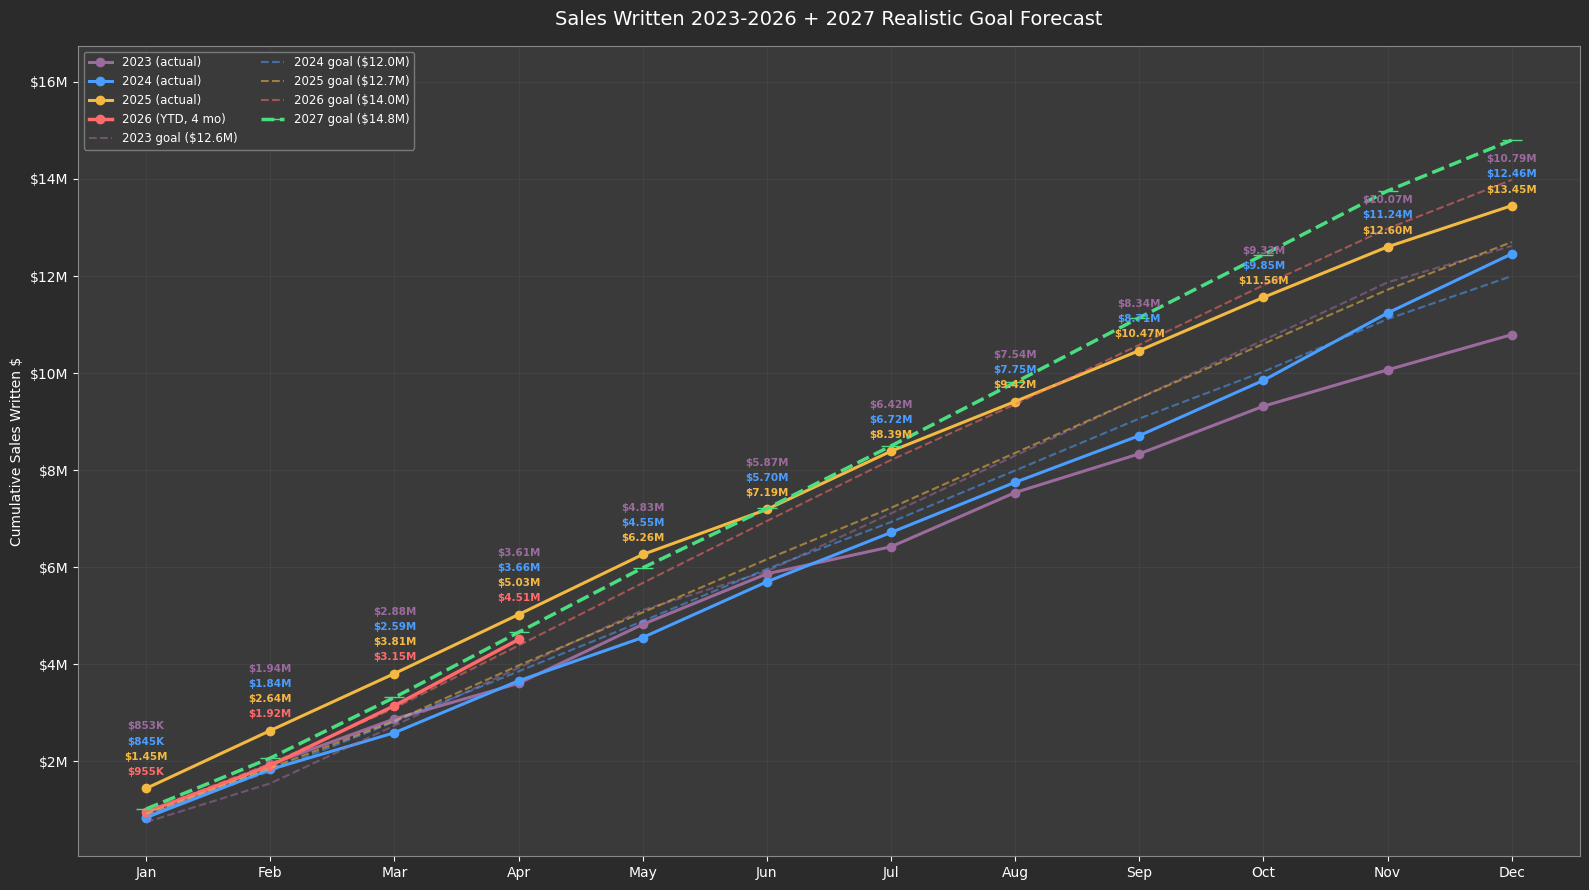

In [5]:
plt.rcParams['figure.facecolor'] = '#2b2b2b'
plt.rcParams['axes.facecolor'] = '#3a3a3a'
plt.rcParams['axes.edgecolor'] = '#888'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['text.color'] = 'white'
plt.rcParams['grid.color'] = '#555'
plt.rcParams['axes.titlecolor'] = 'white'

fig, ax = plt.subplots(figsize=(16, 9))
x = np.arange(12)
colors = {2023: '#9b6b9e', 2024: '#4a9eff', 2025: '#f4b942', 2026: '#ff6b6b'}

def fmt(v):
    return f'${v/1e6:,.2f}M' if v >= 1e6 else f'${v/1e3:,.0f}K'

for yr in [2023, 2024, 2025]:
    if data[yr]['written'][-1] is not None:
        ax.plot(x, data[yr]['written'], marker='o', linewidth=2.2,
                color=colors[yr], label=f'{yr} (actual)')
y2026 = [v for v in data[2026]['written'] if v is not None]
if y2026:
    ax.plot(x[:len(y2026)], y2026, marker='o', linewidth=2.5,
            color=colors[2026], label=f'2026 (YTD, {len(y2026)} mo)')
    
for yr in [2023, 2024, 2025, 2026]:
    goal_traj = data[yr]['goal']
    if all(v is not None for v in goal_traj):
        ax.plot(x, goal_traj, linestyle='--', linewidth=1.5, color=colors[yr],
                alpha=0.55, label=f'{yr} goal (${goal_traj[-1]/1e6:.1f}M)')
if goal_2027 is not None:
    ax.plot(x, goal_2027_monthly, linestyle='--', linewidth=2.5, color='#4ade80',
            marker='_', markersize=14, label=f'2027 goal (${goal_2027/1e6:.1f}M)')

for month_idx in range(12):
    entries = []
    for yr in [2023, 2024, 2025, 2026]:
        v = data[yr]['written'][month_idx]
        if v is not None:
            entries.append((yr, v))
    if not entries:
        continue
    anchor_y = max(v for _, v in entries)
    entries.reverse()
    for stack_pos, (yr, v) in enumerate(entries):
        offset_y = 8 + stack_pos * 11
        ax.annotate(fmt(v), xy=(month_idx, anchor_y), xytext=(0, offset_y), textcoords='offset points', color=colors[yr], fontsize=7.5, ha='center', va='bottom', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_title('Sales Written 2023-2026 + 2027 Realistic Goal Forecast', fontsize=14, pad=15)
ax.set_ylabel('Cumulative Sales Written $')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v/1e6:.0f}M'))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', facecolor='#3a3a3a', edgecolor='#888', labelcolor='white', ncol=2, fontsize=8.5)
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.08)
plt.tight_layout()
plt.show()

## Individual Charts Per Year

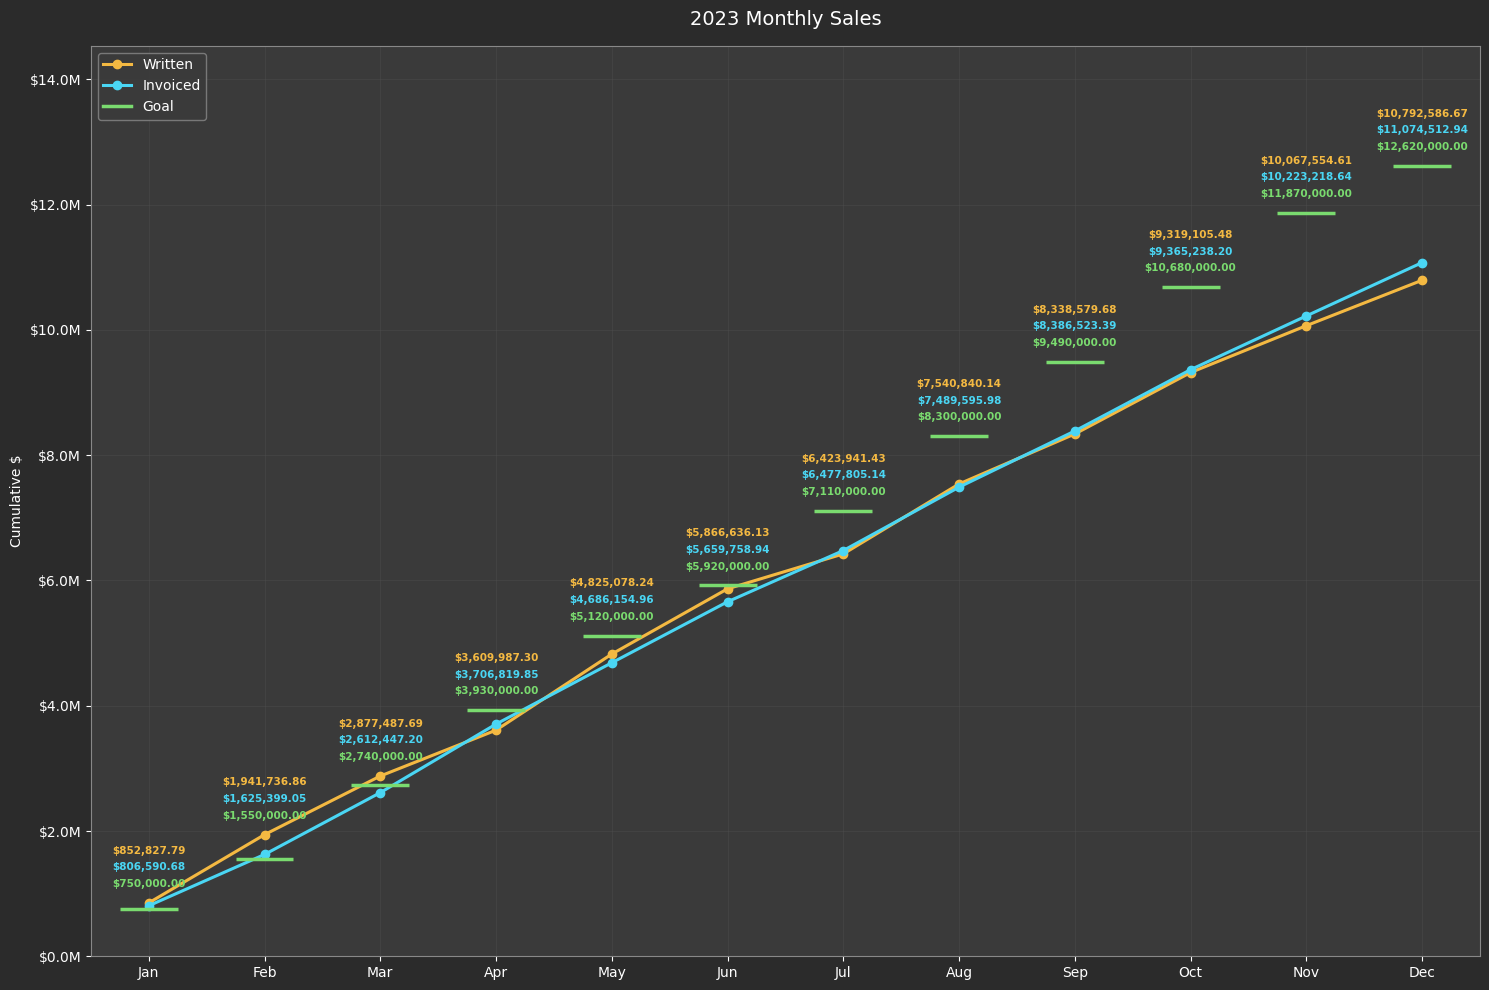

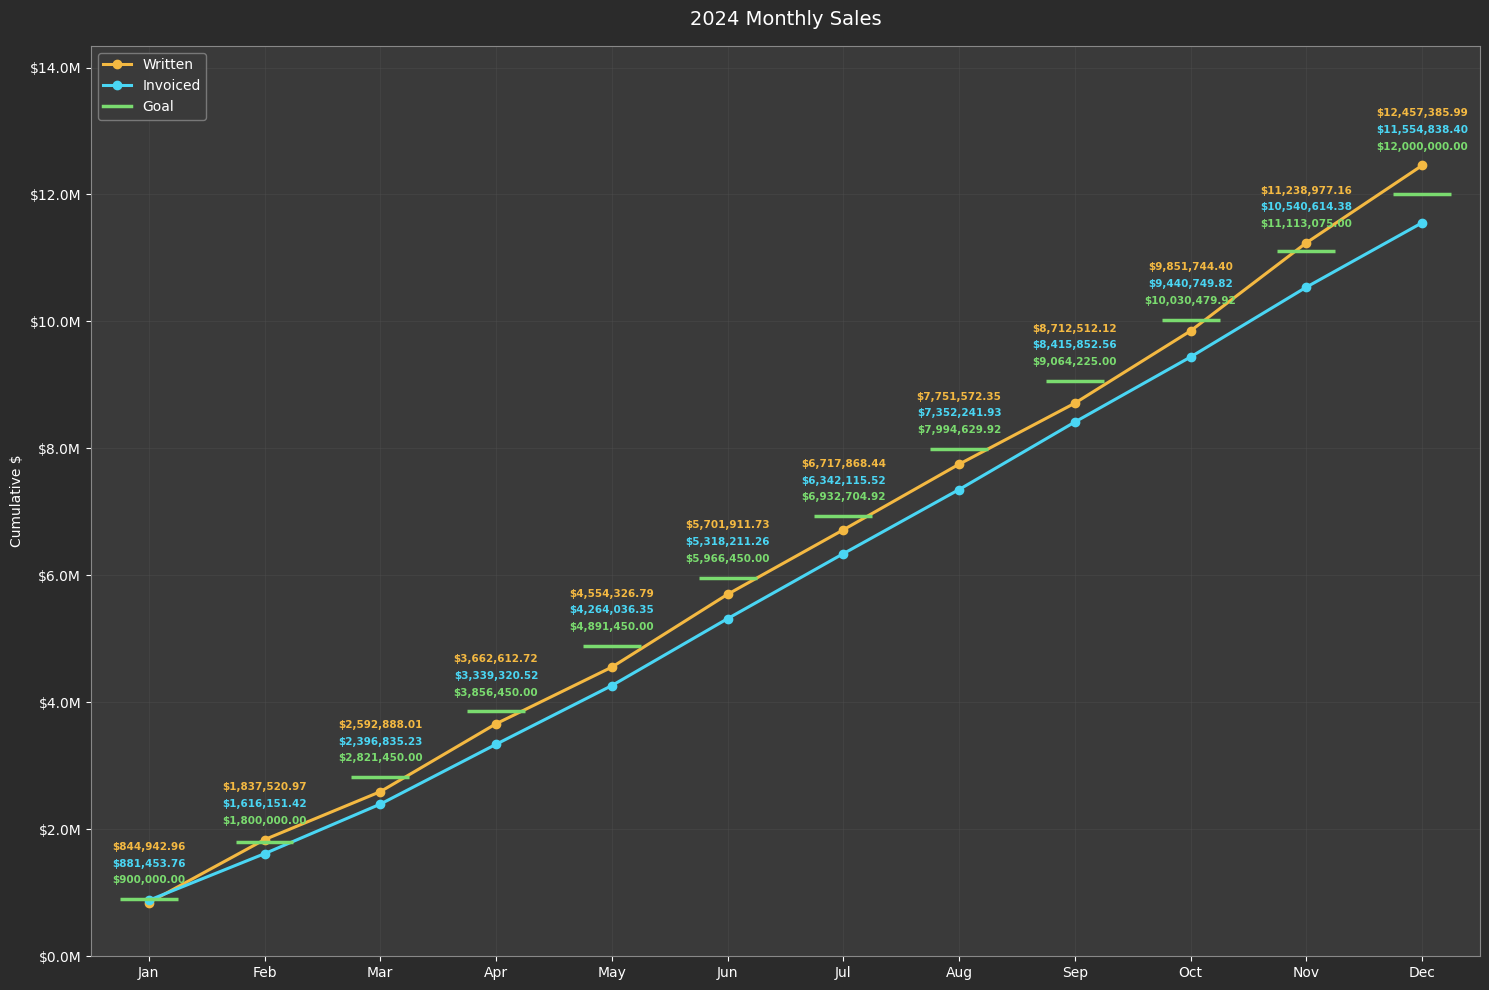

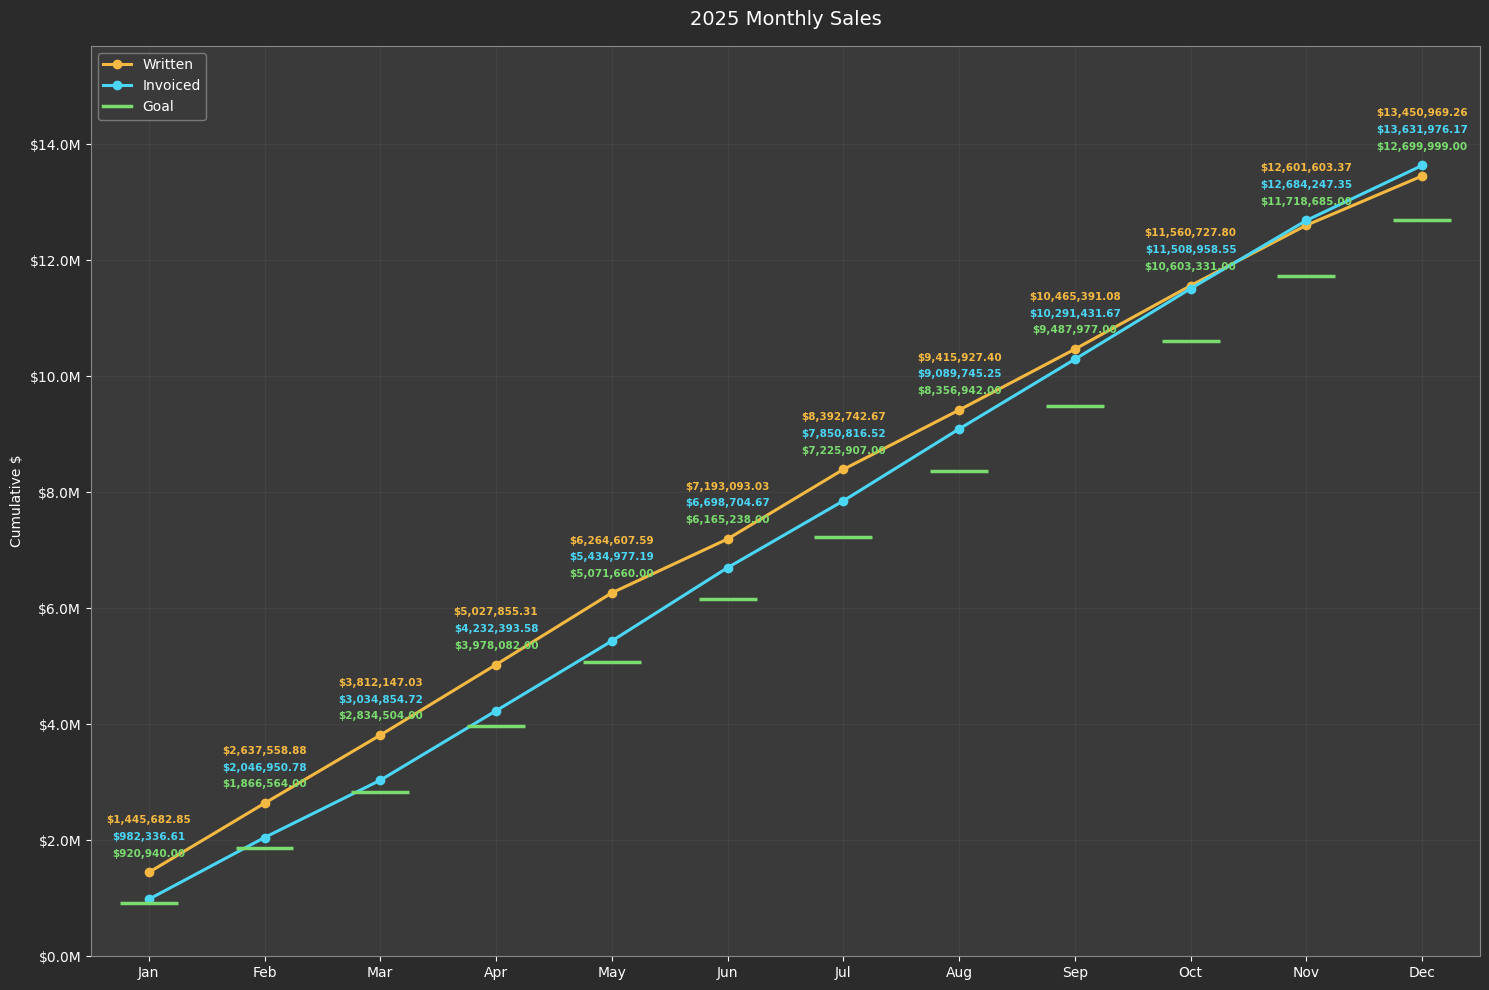

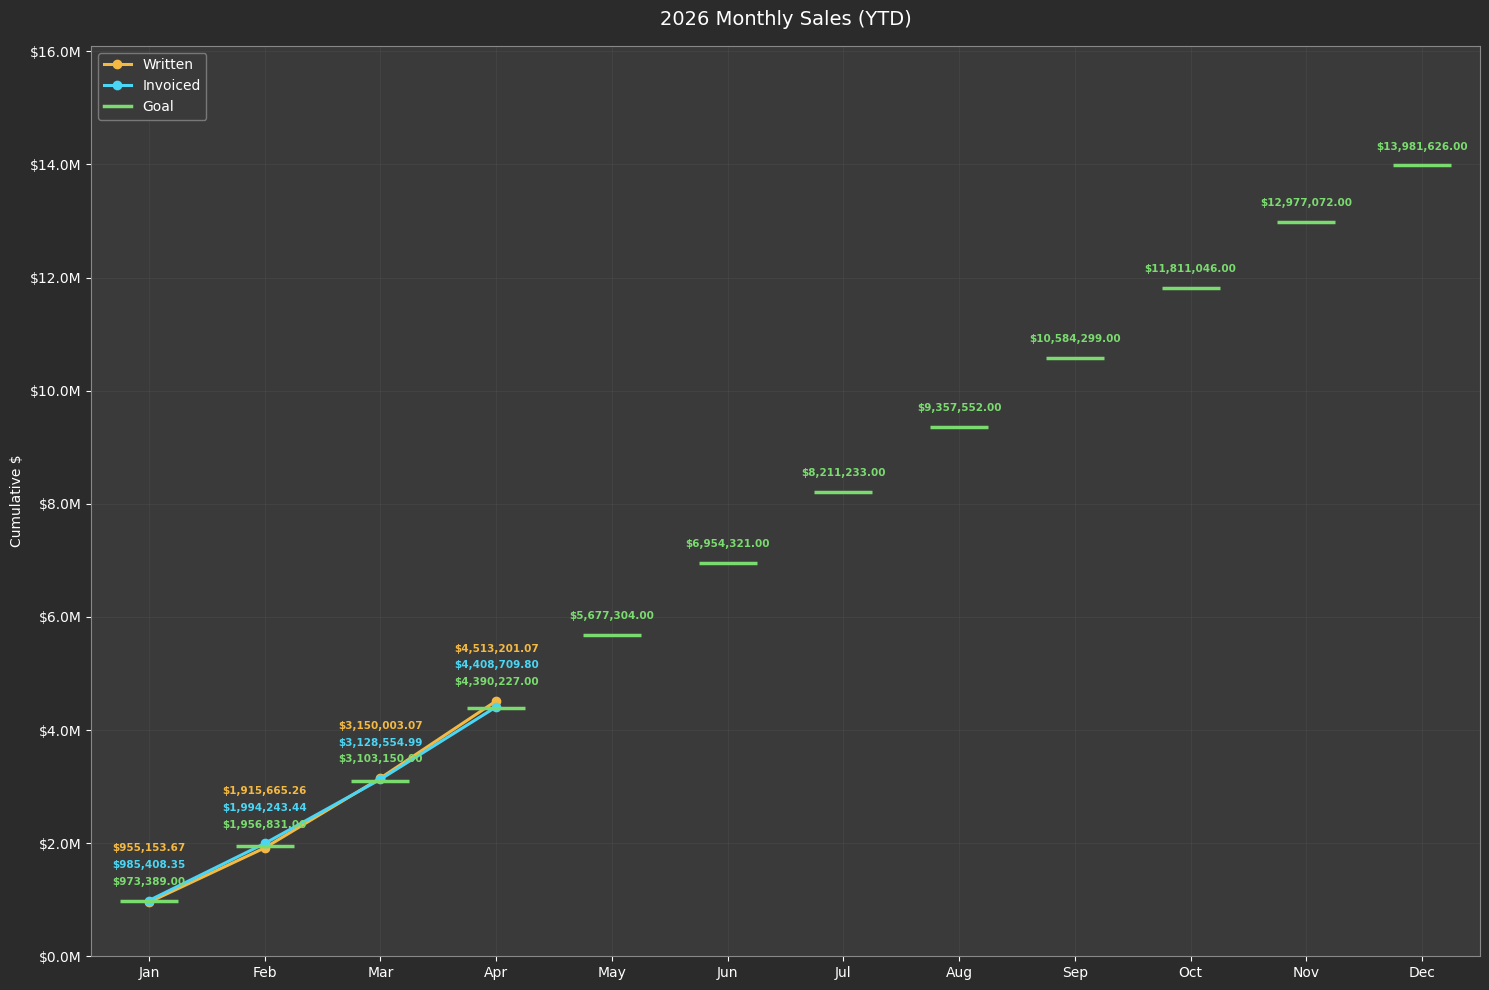

In [6]:
series_colors = {'written':  '#f4b942', 'invoiced': '#4ad6f4', 'goal': '#7adb6f'}
series_labels = {'written': 'Written', 'invoiced': 'Invoiced', 'goal': 'Goal'}

def plot_year(year):
    fig, ax = plt.subplots(figsize=(15, 10))
    x_vals = np.arange(12)
    series = {'written': data[year]['written'], 'invoiced': data[year]['invoiced'], 'goal': data[year]['goal']}
    for key, vals in series.items():
        color = series_colors[key]
        if key == 'goal':
            for i, v in enumerate(vals):
                if v is not None:
                    ax.hlines(v, i - 0.25, i + 0.25, colors=color, linewidth=2.5)
            ax.plot([], [], color=color, linewidth=2.5, label=series_labels[key])
        else:
            xs = [i for i, v in enumerate(vals) if v is not None]
            ys = [v for v in vals if v is not None]
            if xs:
                ax.plot(xs, ys, marker='o', linewidth=2.2, color=color, label=series_labels[key], markersize=6)

    series_order = ['goal', 'invoiced', 'written']
    for i in range(12):
        entries = [(key, series[key][i]) for key in series_order
                   if series[key][i] is not None]
        if not entries:
            continue
        anchor_y = max(v for _, v in entries)
        for stack_pos, (key, v) in enumerate(entries):
            offset_y = 10 + stack_pos * 12
            ax.annotate(f'${v:,.2f}', xy=(i, anchor_y), xytext=(0, offset_y), textcoords='offset points', color=series_colors[key], fontsize=7.5, ha='center', va='bottom', fontweight='bold')

    ax.set_xticks(x_vals)
    ax.set_xticklabels(months)
    is_partial = any(v is None for v in series['written'])
    title = f'{year} Monthly Sales' + (' (YTD)' if is_partial else '')
    ax.set_title(title, fontsize=14, pad=15)
    ax.set_ylabel('Cumulative $')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v/1e6:,.1f}M'))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', facecolor='#3a3a3a', edgecolor='#888', labelcolor='white', fontsize=10)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(0, ymax * 1.1)
    ax.set_xlim(-0.5, 11.5)
    plt.tight_layout()
    plt.show()

for yr in [2023, 2024, 2025, 2026]:
    plot_year(yr)

## Sales by Month Comparison

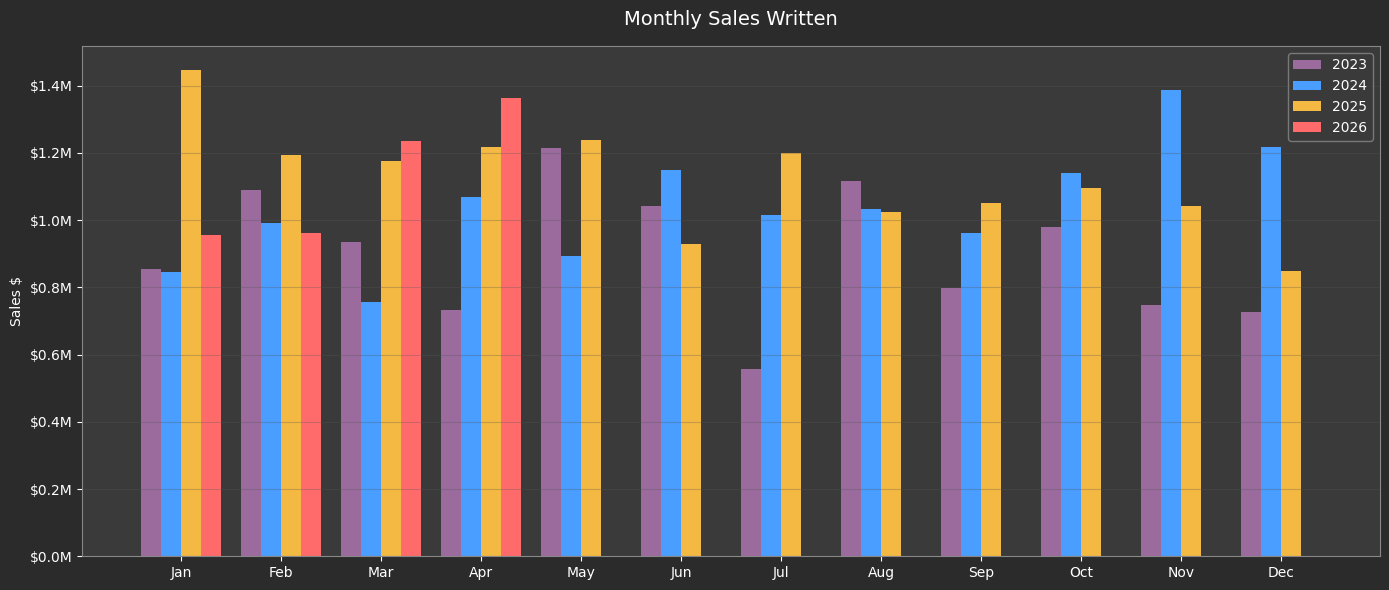

,2023,2024,2025,2026
Jan,852828.0,844943.0,1445683.0,955154.0
Feb,1088909.0,992578.0,1191876.0,960512.0
Mar,935751.0,755367.0,1174588.0,1234338.0
Apr,732500.0,1069725.0,1215708.0,1363198.0
May,1215091.0,891714.0,1236752.0,NaN
Jun,1041558.0,1147585.0,928485.0,NaN
Jul,557305.0,1015957.0,1199650.0,NaN
Aug,1116899.0,1033704.0,1023185.0,NaN
Sep,797740.0,960940.0,1049464.0,NaN
Oct,980526.0,1139232.0,1095337.0,NaN


In [8]:
monthly_incr = {}
for yr in [2023, 2024, 2025, 2026]:
    vals = [v for v in data[yr]['written'] if v is not None]
    if not vals:
        monthly_incr[yr] = [None] * 12
        continue
    incr = [vals[0]] + [vals[i] - vals[i-1] for i in range(1, len(vals))]
    monthly_incr[yr] = incr + [None] * (12 - len(incr))

fig, ax = plt.subplots(figsize=(14, 6))
width = 0.2
for i, yr in enumerate([2023, 2024, 2025, 2026]):
    vals = [v if v is not None else 0 for v in monthly_incr[yr]]
    ax.bar(x + (i - 1.5) * width, vals, width, label=str(yr), color=colors[yr])

ax.set_xticks(x)
ax.set_xticklabels(months)
ax.set_title('Monthly Sales Written', fontsize=14, pad=15)
ax.set_ylabel('Sales $')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v/1e6:.1f}M'))
ax.grid(True, alpha=0.3, axis='y')
ax.legend(facecolor='#3a3a3a', edgecolor='#888', labelcolor='white')
plt.tight_layout()
plt.show()

pd.DataFrame(monthly_incr, index=months).round(0)